In [3]:
import sys
sys.path.append("/Users/sujaladhikari/Sujal's Personal/Projects/FedIDS")

In [4]:
import os 
import shutil
import numpy as np 
import pandas as pd 
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import torch 
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from Model.model import MLP
from torch.optim import Adam
import utils
from utils import JoinCustomDataset
from sklearn.metrics import classification_report
from federatedlearning import hierar_fednova_weight_averageing,fednova_update_from_local
from nids_training import evaluate_model
import matplotlib.pyplot as plt 

### Setting up the device

In [5]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device
RANDOMSEED = 42

### Creating the global model - using the same MLP used for the centralized model 

In [6]:
input_size = 78
hidden_layer = [256, 128,64,8]
num_classes = 2
global_model = MLP(input_size, hidden_layer,num_classes).to(device)
global_model
num_clients = 4

### Creating the Data Configuration and Training Configuration 


In [ ]:
batch_size = 64 ## Initially we set up as same as the centralized model 
lr = 1e-2 ## different learning rate
num_rounds = 20 ## 5/.0001 => 50000 rounds 
num_local_epochs = 1
save_interval = 1

In [8]:
### We will be testing the model in the global dataset, which is the same dataset used to test centralized model and federated model
global_dataset = pd.read_csv('../datasets/global_test_dataset.csv')
global_dataset.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label_Binary
0,-0.135189,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
1,-0.416792,1.913036,0.019771,0.018355,0.090779,-0.002716,0.419670,-0.258335,0.102476,0.316994,...,0.003116,-0.072992,0.060094,-0.005568,-0.085019,0.356508,-0.155389,0.258998,0.444437,0
2,-0.317572,-0.751546,-0.018182,-0.012594,-0.113059,-0.011345,-0.353239,0.267224,-0.176562,-0.375043,...,0.003061,-0.137113,-0.099480,-0.150381,-0.110743,-0.686650,-0.121376,-0.693794,-0.674594,0
3,-0.410492,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
4,-0.439214,-0.349547,-0.005928,-0.010028,-0.077591,-0.006223,-0.204675,-0.258335,-0.232585,-0.172305,...,0.003116,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,0


### Global Metrics used to analyze the global fed nova model 

In [9]:
performance_dict, performance_log = dict(), dict()
metric_keys = ['g_train_loss', 'g_test_loss']
performance_dict, performance_log = utils.performance_analyzer(metric_keys)


### Loading each individual client data 

In [10]:
client_directory = '../FederatedAvg/client_data/nids/'
num_clients = 4

In [11]:
client_loaders = [] ## It has four dataloaders for each client 
for index in range(num_clients):
    features_path = f'client_{index}_X_train.csv'
    labels_path = f'client_{index}_y_train.csv'
    features_directory = os.path.join(client_directory, features_path )
    labels_directory = os.path.join(client_directory, labels_path) 
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True) ## The batch size is 64
    client_loaders.append(dataloader)

### Loading the validation loaders for testing the model's performacen in each epoch in each round 

In [12]:
validation_loaders = []
for index in range(num_clients):
    features_path = f'client_{index}_X_val.csv'
    labels_path = f'client_{index}_y_val.csv'
    features_directory = os.path.join(client_directory, features_path )
    labels_directory = os.path.join(client_directory, labels_path)
    print(features_directory,labels_directory)
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True)
    validation_loaders.append(dataloader)

../FederatedAvg/client_data/nids/client_0_X_val.csv ../FederatedAvg/client_data/nids/client_0_y_val.csv
../FederatedAvg/client_data/nids/client_1_X_val.csv ../FederatedAvg/client_data/nids/client_1_y_val.csv
../FederatedAvg/client_data/nids/client_2_X_val.csv ../FederatedAvg/client_data/nids/client_2_y_val.csv
../FederatedAvg/client_data/nids/client_3_X_val.csv ../FederatedAvg/client_data/nids/client_3_y_val.csv


### Resuming from the check point 

In [13]:
saving_directory = '../hierarFederatedNova/outputhierar/'

In [14]:
# Checking if there is already anything going on 
log_path = os.path.join(saving_directory, 'performanance_log.pickle')
if os.path.isfile(log_path):
    performance_log = utils.loading_pickle(log_path)
starting_round = len(performance_log[metric_keys[0]]) ## Check the list of the stored values (g_train), if the value is greaeter thean 0 then the model is already started and doing its job, and if the model crashes then it can continue from where it left!
if starting_round > 0:
    global_model.load_state_dict(torch.load(os.path.join(saving_directory, 'g_r_{}.pth').format(starting_round))) ## The global model takes the weight from where it left 

### Starting the Federated Nova 

In [ ]:
global_weights = global_model.state_dict() ## This gives the initial weights of the given model
loss_function = nn.CrossEntropyLoss()
optimization_args = {'lr':lr}

for round in range(starting_round, num_rounds):
    print("Round Number:", round)
    global_model.train()
    client_updates = dict()

    for client_number in range(num_clients):
        print("Client", client_number)
        client_loader = client_loaders[client_number] ## Loading each clients data
        validation_loader = validation_loaders[client_number] ## Loading each clients validation data 
        client_update = fednova_update_from_local(global_model, client_loader, validation_loader, num_local_epochs, optimization_args)

        client_updates.setdefault('delta_weight', list()).append(client_update['delta_weights'])
        client_updates.setdefault('number_samples', list()).append(client_update['num_samples'])
        client_updates.setdefault('tau_k', list()).append(client_update['tau_k'])

        performance_log.setdefault('c_{}_train_loss'.format(client_number), list()).append(client_update['training_loss'])
        ## Train loss of each client using the global model on training data 
        performance_log.setdefault('c_{}_test_loss'.format(client_number), list()).append(client_update['testing_loss'])
    
    
    global_weights = hierar_fednova_weight_averageing(global_model, client_updates['delta_weight'], client_updates['number_samples'], client_updates['tau_k'], device, alpha=0.8, server_learning_rate = 2.0)
    global_model.load_state_dict(global_weights)

    for client_index in range(num_clients):
        g_train_loss = evaluate_model(global_model, client_loaders[client_index], loss_function, tqdm_desc = 'g_train_loss')
        print(g_train_loss)
        performance_dict['g_train_loss'].update_state(g_train_loss)
        g_test_loss = evaluate_model(global_model, validation_loaders[client_index], loss_function, tqdm_desc='Validation Loss' )
        performance_dict['g_test_loss'].update_state(g_test_loss)
    
    performance_log['g_train_loss'].append(performance_dict['g_train_loss'].result())
    performance_log['g_test_loss'].append(performance_dict['g_test_loss'].result())
    performance_dict['g_train_loss'].reset_state()
    performance_dict['g_test_loss'].reset_state()

## Saving the model 
    for metric in metric_keys:
        print(f"{metric}: {performance_log[metric][-1]}")

    ## Saving the global model 

    if (round + 1)  % save_interval == 0: 
        torch.save(global_model.state_dict(), os.path.join(saving_directory, 'g_r_{}.pth'.format(round+1))) ## Saving the global model's weights in the given directory with the name g_r_1..n.pth
        utils.savein_pickle(log_path,performance_log)  ## Storing the overall value in the pickle form to access it later 


In [16]:
### Analysis of the global model, on each of the train and test loss 
import pickle
with open('./outputhierar/performanance_log.pickle', 'rb') as f: 
    losses = pickle.load(f)

data = pd.DataFrame(losses)
data.index.name = 'Round'
data = data.reset_index()
data.head(20)

,Round,g_train_loss,g_test_loss,c_0_train_loss,c_0_test_loss,c_1_train_loss,c_1_test_loss,c_2_train_loss,c_2_test_loss,c_3_train_loss,c_3_test_loss
0,0,0.694152,0.693621,0.036065,0.036768,0.053554,0.052324,0.049067,0.074980,0.665282,0.664851
1,1,0.694130,0.693598,0.033629,0.034854,0.050144,0.049075,0.048475,0.074236,0.664921,0.664497
2,2,0.694105,0.693574,0.033317,0.034496,0.050691,0.049728,0.048776,0.074924,0.664537,0.664121
3,3,0.694080,0.693548,0.033787,0.034978,0.051419,0.050286,0.048541,0.074230,0.664123,0.663717
4,4,0.694054,0.693523,0.032453,0.033466,0.051879,0.050971,0.048051,0.073455,0.663733,0.663335
5,5,0.694028,0.693498,0.033483,0.034682,0.051432,0.050410,0.048054,0.073609,0.663371,0.662980
6,6,0.694002,0.693472,0.033206,0.034364,0.051904,0.050887,0.047974,0.073179,0.662953,0.662572
7,7,0.693977,0.693447,0.033079,0.034240,0.050458,0.049399,0.048929,0.074248,0.662598,0.662230
8,8,0.693950,0.693421,0.033390,0.034623,0.051554,0.050433,0.047749,0.072804,0.662227,0.661862
9,9,0.693922,0.693393,0.031577,0.032524,0.052095,0.050844,0.047331,0.072167,0.661850,0.661489


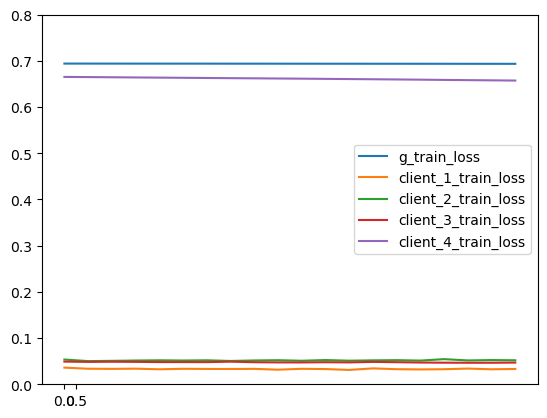

In [17]:
plt.plot(data['g_train_loss'], label = 'g_train_loss')
plt.plot(data['c_0_train_loss'], label = 'client_1_train_loss')
plt.plot(data['c_1_train_loss'], label = 'client_2_train_loss')
plt.plot(data['c_2_train_loss'], label = 'client_3_train_loss')
plt.plot(data['c_3_train_loss'], label = 'client_4_train_loss')
plt.xticks(np.arange(0,0.8,0.5))
plt.ylim(0,0.8)
plt.legend()
plt.show()

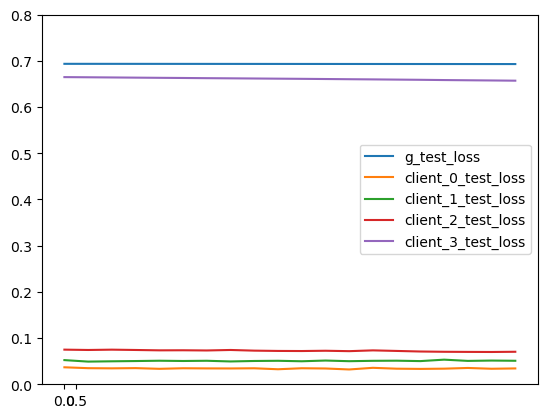

In [18]:
plt.plot(data['g_test_loss'], label = 'g_test_loss')
plt.plot(data['c_0_test_loss'], label = 'client_0_test_loss')
plt.plot(data['c_1_test_loss'], label = 'client_1_test_loss')
plt.plot(data['c_2_test_loss'], label = 'client_2_test_loss')
plt.plot(data['c_3_test_loss'], label = 'client_3_test_loss')
plt.xticks(np.arange(0,0.8,0.5))
plt.ylim(0,0.8)
plt.legend()
plt.show()

In [19]:
criterion = nn.CrossEntropyLoss()
def post_trained_global_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    total = 0 
    correct = 0 
    true_labels = []
    prediction = []

    with torch.no_grad():
        for samples, features in test_loader:
            samples = samples.to(device)
            features = features.to(device)
            output = model(samples)
            loss = criterion(output, features)
            _, predicted = output.max(1)
            prediction.extend(predicted.tolist())
            total += features.size(0)
            test_loss += loss.item()
            correct += predicted.eq(features).sum().item()
            true_labels.extend(features.tolist())

        test_loss = test_loss/len(test_loader.dataset)
        accuracy = 100* correct / total 
    
    return test_loss, accuracy, prediction, true_labels

In [20]:
global_dataset.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label_Binary
0,-0.135189,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
1,-0.416792,1.913036,0.019771,0.018355,0.090779,-0.002716,0.419670,-0.258335,0.102476,0.316994,...,0.003116,-0.072992,0.060094,-0.005568,-0.085019,0.356508,-0.155389,0.258998,0.444437,0
2,-0.317572,-0.751546,-0.018182,-0.012594,-0.113059,-0.011345,-0.353239,0.267224,-0.176562,-0.375043,...,0.003061,-0.137113,-0.099480,-0.150381,-0.110743,-0.686650,-0.121376,-0.693794,-0.674594,0
3,-0.410492,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
4,-0.439214,-0.349547,-0.005928,-0.010028,-0.077591,-0.006223,-0.204675,-0.258335,-0.232585,-0.172305,...,0.003116,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,0


In [21]:
### Saving the model 
saving_directory = '../models/'

In [22]:
log_path = os.path.join(saving_directory, 'hierarfednova.pickle')
utils.savein_pickle(log_path,global_model)

In [23]:
scaler = StandardScaler()
def batch_maker(dataset):
    dataset = dataset.drop(columns = 'Unnamed: 0', errors='ignore')
    X = dataset.drop(columns = 'Label_Binary')
    X = X.to_numpy()
    y = dataset['Label_Binary']
    y = y.to_numpy()
    X_train , X_test, y_train, y_test = train_test_split(X,y , test_size=0.3, random_state=42)
    X_train = scaler.fit_transform(X_train)
    X_train = torch.tensor(X_train, dtype = torch.float32)
    y_train = torch.tensor(y_train, dtype = torch.long)

    X_test = scaler.transform(X_test)
    X_test = torch.tensor(X_test, dtype = torch.float32)
    y_test = torch.tensor(y_test, dtype = torch.long)

    training_batch = DataLoader(TensorDataset(X_train,y_train), batch_size = 64, shuffle = True)
    testing_batch = DataLoader(TensorDataset(X_test,y_test), batch_size=64, shuffle=False)
    
    return training_batch,testing_batch 

### Analysis of the global model on each client after the completing all the rounds of training the global model 

In [24]:
siloOne_train, siloOne_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryOne.csv'))
siloTwo_train, siloTwo_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryTwo.csv'))
siloThree_train, siloThree_test= batch_maker(pd.read_csv('../silos_datasets/siloBinaryThree.csv'))
siloFour_train, siloFour_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryFour.csv'))

KeyboardInterrupt: 

In [ ]:
criterion = nn.CrossEntropyLoss()
def post_trained_global_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    total = 0 
    correct = 0 
    true_labels = []
    prediction = []

    with torch.no_grad():
        for samples, features in test_loader:
            samples = samples.to(device)
            features = features.to(device)
            output = model(samples)
            loss = criterion(output, features)
            _, predicted = output.max(1)
            prediction.extend(predicted.tolist())
            total += features.size(0)
            test_loss += loss.item()
            correct += predicted.eq(features).sum().item()
            true_labels.extend(features.tolist())

        test_loss = test_loss/len(test_loader.dataset)
        accuracy = 100* correct / total 
    
    return test_loss, accuracy, prediction, true_labels

In [ ]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloOne_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0104, Test Accuracy: 85.4206%
              precision    recall  f1-score   support

           0       0.80      0.94      0.87     75551
           1       0.92      0.77      0.84     75477

    accuracy                           0.85    151028
   macro avg       0.86      0.85      0.85    151028
weighted avg       0.86      0.85      0.85    151028



In [ ]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloTwo_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0108, Test Accuracy: 49.5178%
              precision    recall  f1-score   support

           0       0.50      0.99      0.66     86566
           1       0.15      0.00      0.00     86705

    accuracy                           0.50    173271
   macro avg       0.33      0.50      0.33    173271
weighted avg       0.33      0.50      0.33    173271



In [ ]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloThree_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0109, Test Accuracy: 48.7831%
              precision    recall  f1-score   support

           0       0.50      0.96      0.66      4207
           1       0.00      0.00      0.00      4093

    accuracy                           0.49      8300
   macro avg       0.25      0.48      0.33      8300
weighted avg       0.25      0.49      0.33      8300



In [ ]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloFour_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0112, Test Accuracy: 50.0772%
              precision    recall  f1-score   support

           0       0.51      0.98      0.67       665
           1       0.00      0.00      0.00       631

    accuracy                           0.50      1296
   macro avg       0.25      0.49      0.33      1296
weighted avg       0.26      0.50      0.34      1296

